In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
from lobster import *

In [3]:
ticker = "INTC"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
#[["type", "lvl", "size", "P_1", "Q_1", "P_-1", "Q_-1", "P_2", "Q_2", "P_-2", "Q_-2", "P_3", "Q_3", "P_-3", "Q_-3", "P_4", "Q_4", "P_-4", "Q_-4", "P_5", "Q_5", "P_-5", "Q_-5"]]
df

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,100,275150.0,275200.0,166,...,200,275500.0,0,274800.0,661,275600.0,100,274700.0,300,1
1,34200.006462,0.000221,0.000221,L,275500,4,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
2,34200.048864,0.042402,0.042623,C,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
3,34200.048883,0.000020,0.042642,C,275100,-1,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
4,34200.048989,0.000106,0.000125,L,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580346,57599.860444,0.011408,0.011408,C,267200,1,34600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580347,57599.860635,0.000191,0.223738,L,267000,-2,16600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580348,57599.870108,0.009473,0.249387,C,267400,3,600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580349,57599.939645,0.069536,0.079201,L,267200,1,100,267150.0,267200.0,88204,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157


In [4]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,197.19,162.42,324.82,483.88,119.1
2,40.20,59.75,0.00,441.55,462.3
3,22.71,22.55,0.00,451.23,1004.4
4,13.23,11.88,0.00,475.07,1672.0
5,9.50,8.44,0.00,596.93,2263.0


In [5]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head(10)

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
5,34200.049011,0.000022,0.042770,L,274900,-3,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
6,34200.049078,0.000068,0.042837,L,274800,-4,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,1,1
7,34200.049110,0.000032,0.042869,L,274700,-5,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
8,34200.049301,0.000190,0.000311,L,275000,-2,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
9,34200.211338,0.162038,0.205097,M,275200,1,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1


In [55]:
print("Average Limit Size", df_norm[(df_norm["type"]=="L") & (abs(df_norm["lvl"])==1)]["size"].mean())
print("Average Cancel Size", df_norm[(df_norm["type"]=="C") & (abs(df_norm["lvl"])==1)]["size"].mean())
print("Average Market Size", df_norm[(df_norm["type"]=="M") & (abs(df_norm["lvl"])==1)]["size"].mean())

Average Limit Size 1.6776068237370305
Average Cancel Size 1.6462852252507403
Average Market Size 1.3429283911089218


In [62]:
df_norm.describe().loc["max"]

time      57599.948442
dtk           6.972331
dtk_l        97.090885
price         276300.0
lvl                5.0
size             171.0
pref          275950.0
P_1           276000.0
Q_1              322.0
P_-1          275900.0
Q_-1             312.0
P_2           276100.0
Q_2              398.0
P_-2          275800.0
Q_-2             341.0
P_3           276200.0
Q_3              246.0
P_-3          275700.0
Q_-3             168.0
P_4           276300.0
Q_4              160.0
P_-4          275600.0
Q_-4             156.0
P_5           276400.0
Q_5              117.0
P_-5          275500.0
Q_-5             124.0
seg_id          1157.0
Name: max, dtype: Float64

### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [6]:
df_train = df_norm.copy()

def build_training_dfs_by_level(df_train):
    event_map = {"L": 0, "C": 1, "M": 2}
    out = {}

    for lvl, df in df_train.groupby("lvl"):
        df = df.copy()

        # 1) Event ID
        df["event_id"] = df["type"].map(event_map)

        # 2) Hour of last event
        df["hour_last_event"] = df["time"].shift(1) // 3600

        # 3) Last event ID
        df["last_event_id"] = df["event_id"].shift(1)

        # 4) Queue before event
        df["q"] = df[f"Q_{lvl}"].shift(1)

        # Formatting
        df = df.dropna().reset_index(drop=True)
        df["hour_last_event"] = df["hour_last_event"].astype("int64")
        hour_map = {h: i for i, h in enumerate(sorted(df["hour_last_event"].unique()))}
        df["hour_last_event"] = df["hour_last_event"].map(hour_map)
        df["last_event_id"] = df["last_event_id"].astype("int64")
        df["q"] = df["q"].astype("int64")

        out[lvl] = df[["event_id", "dtk_l", "q", "hour_last_event", "last_event_id"]]

    return out

def build_training_dfs_by_abs_level(df_train):
    dfs_by_level = build_training_dfs_by_level(df_train)
    dfs_by_abs_level = {}

    abs_levels = sorted({abs(lvl) for lvl in dfs_by_level.keys()})

    for k in abs_levels:
        parts = []
        if -k in dfs_by_level:
            parts.append(dfs_by_level[-k].copy())
        if k in dfs_by_level:
            parts.append(dfs_by_level[k].copy())

        if parts:
            dfs_by_abs_level[k] = pd.concat(parts, ignore_index=True)

    return dfs_by_abs_level

In [7]:
dfs_by_abs_level = build_training_dfs_by_abs_level(df_train)
print(dfs_by_abs_level.keys())

dict_keys([1, 2, 3, 4, 5])


In [8]:
dfs_by_abs_level[1]

,event_id,dtk_l,q,hour_last_event,last_event_id
0,0,0.162572,1,0,1
1,0,0.000007,2,0,0
2,0,0.000002,2,0,0
3,1,0.000094,2,0,0
4,0,0.000000,2,0,1
...,...,...,...,...,...
392088,1,0.010125,256,6,1
392089,1,0.206373,253,6,1
392090,0,0.014818,252,6,1
392091,1,0.011408,254,6,0


### QR Model Intensities ###

In [9]:
from qrFunctions import shift_orderbook_before_event, build_all_sequences, estimate_all_qr
df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)
seqs = build_all_sequences(df_qr, K=5)
lambdas, Ns, Ts = estimate_all_qr(seqs)

In [10]:
from qrFunctions import qr_transition_matrix
qr_matrix = qr_transition_matrix(Ns, K=K)
qr_matrix

,cancel,limit,trade
cancel,0.456695,0.487335,0.05597
limit,0.456695,0.487335,0.05597
trade,0.456695,0.487335,0.05597


### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [11]:
from dqrfunctions import build_dataset

df_train_1 = build_dataset(dfs_by_abs_level[1], use_hour=True, use_last_event=True)
df_train_2 = build_dataset(dfs_by_abs_level[2], use_hour=True, use_last_event=True)
df_train_3 = build_dataset(dfs_by_abs_level[3], use_hour=True, use_last_event=True)
df_train_4 = build_dataset(dfs_by_abs_level[4], use_hour=True, use_last_event=True)
df_train_5 = build_dataset(dfs_by_abs_level[5], use_hour=True, use_last_event=True)

display(df_train_1)

{'q': tensor([  1.,   2.,   2.,  ..., 252., 254., 183.]),
 'y': tensor([0, 0, 0,  ..., 0, 1, 0]),
 'dt': tensor([1.6257e-01, 6.8950e-06, 1.5020e-06,  ..., 1.4818e-02, 1.1408e-02,
         7.9201e-02]),
 'last_event': tensor([1, 0, 0,  ..., 1, 0, 1]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

### Neural Network Definition ###

In [12]:
from dqrfunctions import DQRNet

### Negative Log Likelihood ###

$\text{loss}\left(\theta | \epsilon\right) = l\left(\lambda_\theta | \epsilon\right) = \sum_{i=1}^{B} \left( \Lambda_\theta(x_k)\Delta t_k - \log{\lambda_\theta^{\eta_k}(x_k)} \right)$

In [13]:
from dqrfunctions import dqr_loss

### Training Loop ###

In [14]:
from dqrfunctions import train_model, get_or_train_model

### Model Training ###

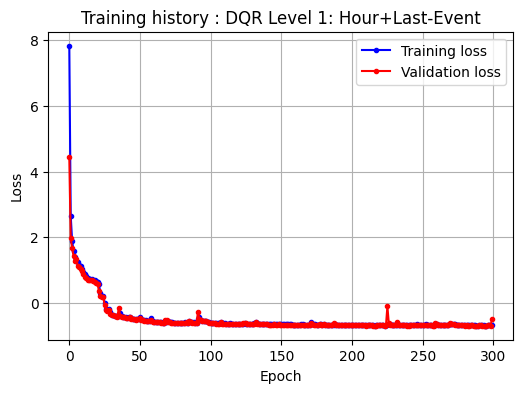

In [15]:
model_level_1 = get_or_train_model(
    f"models/{ticker}/dqr_level_1.pt",
    data=df_train_1,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[1]["hour_last_event"].nunique())
model_level_1.plot_history(model_name="Level 1: Hour+Last-Event")

In [16]:
model_level_2 = get_or_train_model(
    f"models/{ticker}/dqr_level_2.pt",
    data=df_train_2,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[2]["hour_last_event"].nunique())

In [17]:
model_level_3 = get_or_train_model(
    f"models/{ticker}/dqr_level_3.pt",
    data=df_train_3,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[3]["hour_last_event"].nunique())

In [18]:
model_level_4 = get_or_train_model(
    f"models/{ticker}/dqr_level_4.pt",
    data=df_train_4,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[4]["hour_last_event"].nunique())

In [19]:
model_level_5 = get_or_train_model(
    f"models/{ticker}/dqr_level_5.pt",
    data=df_train_5,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[5]["hour_last_event"].nunique())

### Simulation of LOB ###

In [29]:
Q_MAX = 500
TICK_SIZE = 50
MARKET_OPEN_S = 34200  # 9:30:00 par exemple


def get_hour_id(abs_time_s, t_start=MARKET_OPEN_S, max_hour_id=6):
    return min(int((t_start + abs_time_s) // 3600) - int(t_start // 3600), max_hour_id)


def model_intensities(model, q_val, last_event, hour_id, device="cpu"):
    model.eval()
    with torch.no_grad():
        x_q = torch.tensor([q_val], dtype=torch.float32, device=device)
        x_last = torch.tensor([last_event], dtype=torch.long, device=device)
        x_hour = torch.tensor([hour_id], dtype=torch.long, device=device)

        # ordre correct : (q, last_event, hour)
        out = model(x_q, x_last, x_hour)

        if out.dim() == 2:
            out = out[0]

        lam = out.detach().cpu().numpy().astype(float)

    lam = np.clip(lam, 1e-12, None)
    return lam


def compute_book_snapshot(pref, qa, qb, K=5, tick_size=50):
    """
    Construit un dictionnaire avec colonnes type:
    P_1, Q_1, ..., P_5, Q_5, P_-1, Q_-1, ..., P_-5, Q_-5
    """
    snap = {"pref": pref}

    for l in range(1, K + 1):
        snap[f"P_{l}"] = pref + l * tick_size
        snap[f"Q_{l}"] = int(qa[l - 1])

    for l in range(1, K + 1):
        snap[f"P_-{l}"] = pref - l * tick_size
        snap[f"Q_-{l}"] = int(qb[l - 1])

    return snap


def shift_book_after_ask_depletion(qa, qb, last_ask, last_bid, refill_ask=1, refill_bid=1):
    """
    qa[0] vidé -> le prix monte.
    On décale les niveaux.
    """
    qa = np.roll(qa, -1)
    qa[-1] = refill_ask

    qb = np.roll(qb, 1)
    qb[0] = refill_bid

    last_ask = np.roll(last_ask, -1)
    last_ask[-1] = 0

    last_bid = np.roll(last_bid, 1)
    last_bid[0] = 0

    return qa, qb, last_ask, last_bid


def shift_book_after_bid_depletion(qa, qb, last_ask, last_bid, refill_ask=1, refill_bid=1):
    """
    qb[0] vidé -> le prix baisse.
    On décale les niveaux.
    """
    qb = np.roll(qb, -1)
    qb[-1] = refill_bid

    qa = np.roll(qa, 1)
    qa[0] = refill_ask

    last_bid = np.roll(last_bid, -1)
    last_bid[-1] = 0

    last_ask = np.roll(last_ask, 1)
    last_ask[0] = 0

    return qa, qb, last_ask, last_bid


def simulate_dqr_day(
    models_by_level,
    init_qa,
    init_qb,
    K=5,
    T_sim=23400.0,
    t_start=MARKET_OPEN_S,
    pref0=275150.0,
    tick_size=TICK_SIZE,
    q_max=Q_MAX,
    max_events=2_000_000,
    device="cpu",
    refill_mode="constant",
    refill_value=1,
    empirical_q_ask=None,
    empirical_q_bid=None,
):
    """
    models_by_level: dict ou liste indexée par niveau absolu
        ex: {1: model_level_1, ..., 5: model_level_5}

    init_qa, init_qb: tailles initiales ask/bid de longueur K
    """

    qa = np.array(init_qa, dtype=float).copy()
    qb = np.array(init_qb, dtype=float).copy()

    last_ask = np.zeros(K, dtype=int)
    last_bid = np.zeros(K, dtype=int)

    pref = float(pref0)
    t = 0.0
    seg_id = 1
    dt_since_seg_start = 0.0

    rows = []

    for _ in range(max_events):
        if t >= T_sim:
            break

        hour_id = get_hour_id(t, t_start=t_start)

        # 1) Construire toutes les intensités élémentaires
        # événements = (side, level_abs, event_type, intensity)
        # side = +1 ask, -1 bid
        event_list = []

        for l in range(1, K + 1):
            model = models_by_level[l]

            lam_ask = model_intensities(
                model=model,
                q_val=float(qa[l - 1]),
                last_event=int(last_ask[l - 1]),
                hour_id=int(hour_id),
                device=device,
            )

            lam_bid = model_intensities(
                model=model,
                q_val=float(qb[l - 1]),
                last_event=int(last_bid[l - 1]),
                hour_id=int(hour_id),
                device=device,
            )

            # sécurité: si queue vide, pas de cancel/market possibles
            if qa[l - 1] <= 0:
                lam_ask[1:] = 0.0
            if qb[l - 1] <= 0:
                lam_bid[1:] = 0.0

            # market order uniquement au niveau 1
            if l > 1 and len(lam_ask) >= 3:
                lam_ask[2] = 0.0
                lam_bid[2] = 0.0

            # side = +1 ask, -1 bid
            for ev_type in range(len(lam_ask)):
                event_list.append((+1, l, ev_type, lam_ask[ev_type]))
            for ev_type in range(len(lam_bid)):
                event_list.append((-1, l, ev_type, lam_bid[ev_type]))

        lambdas = np.array([x[3] for x in event_list], dtype=float)
        Lambda = lambdas.sum()

        if Lambda <= 0:
            break

        # 2) Tirage du prochain temps
        dt = np.random.exponential(scale=1.0 / Lambda)
        t += dt
        if t > T_sim:
            break

        dt_since_seg_start += dt

        # 3) Tirage du type d'événement
        idx = np.random.choice(len(event_list), p=lambdas / Lambda)
        side, level_abs, ev_type, _ = event_list[idx]

        # conventions
        # ev_type: 0=L, 1=C, 2=M
        type_str = {0: "L", 1: "C", 2: "M"}[ev_type]
        signed_lvl = level_abs if side == +1 else -level_abs
        size = 1

        # 4) Mise à jour du carnet
        price_moved = False

        if side == +1:
            # ASK side
            i = level_abs - 1

            if ev_type == 0:  # Limit
                qa[i] = min(qa[i] + 1, q_max)

            elif ev_type in [1, 2]:  # Cancel ou Market
                if qa[i] > 0:
                    qa[i] -= 1

            last_ask[i] = ev_type

        else:
            # BID side
            i = level_abs - 1

            if ev_type == 0:  # Limit
                qb[i] = min(qb[i] + 1, q_max)

            elif ev_type in [1, 2]:  # Cancel ou Market
                if qb[i] > 0:
                    qb[i] -= 1

            last_bid[i] = ev_type

        # 5) Gestion des mouvements de prix
        while qa[0] <= 0:
            price_moved = True
            pref += tick_size

            if refill_mode == "empirical" and empirical_q_ask is not None and empirical_q_bid is not None:
                refill_ask = float(np.random.choice(empirical_q_ask))
                refill_bid = float(np.random.choice(empirical_q_bid))
            else:
                refill_ask = refill_value
                refill_bid = refill_value

            qa, qb, last_ask, last_bid = shift_book_after_ask_depletion(
                qa, qb, last_ask, last_bid,
                refill_ask=refill_ask,
                refill_bid=refill_bid
            )

            seg_id += 1
            dt_since_seg_start = 0.0

        while qb[0] <= 0:
            price_moved = True
            pref -= tick_size

            if refill_mode == "empirical" and empirical_q_ask is not None and empirical_q_bid is not None:
                refill_ask = float(np.random.choice(empirical_q_ask))
                refill_bid = float(np.random.choice(empirical_q_bid))
            else:
                refill_ask = refill_value
                refill_bid = refill_value

            qa, qb, last_ask, last_bid = shift_book_after_bid_depletion(
                qa, qb, last_ask, last_bid,
                refill_ask=refill_ask,
                refill_bid=refill_bid
            )

            seg_id += 1
            dt_since_seg_start = 0.0

        # 6) Snapshot
        row = {
            "time": t_start + t,
            "dtk": dt,
            "dtk_l": dt_since_seg_start,
            "type": type_str,
            "price": pref + signed_lvl * tick_size,
            "lvl": signed_lvl,
            "size": size,
            "pref": pref,
            "hour_id": hour_id,
            "seg_id": seg_id,
        }

        row.update(compute_book_snapshot(pref, qa, qb, K=K, tick_size=tick_size))
        rows.append(row)

    df_sim = pd.DataFrame(rows)
    return df_sim

In [30]:
print(model_level_1(
    torch.tensor([10.0], dtype=torch.float32),
    torch.tensor([0], dtype=torch.long),
    torch.tensor([0], dtype=torch.long)
))

tensor([[6.4722, 4.8883, 0.1581]], grad_fn=<ReluBackward0>)


In [91]:
models_by_level = {
    1: model_level_1,
    2: model_level_2,
    3: model_level_3,
    4: model_level_4,
    5: model_level_5,
}

init_qa = [10, 12, 15, 18, 20]
init_qb = [11, 13, 14, 17, 21]

df_sim = simulate_dqr_day(
    models_by_level=models_by_level,
    init_qa=init_qa,
    init_qb=init_qb,
    K=5,
    T_sim=3600.0,
    t_start=34200.0,
    pref0=275150.0,
    tick_size=100,
    q_max=500,
    device="cpu",
    refill_mode="empirical",   # ou "empirical"
    refill_value=5
)

df_sim

,time,dtk,dtk_l,type,price,lvl,size,pref,hour_id,seg_id,...,P_-1,Q_-1,P_-2,Q_-2,P_-3,Q_-3,P_-4,Q_-4,P_-5,Q_-5
0,34200.013054,0.013054,0.013054,L,275250.0,1,1,275150.0,0,1,...,275050.0,11,274950.0,13,274850.0,14,274750.0,17,274650.0,21
1,34200.020094,0.007040,0.020094,L,275250.0,1,1,275150.0,0,1,...,275050.0,11,274950.0,13,274850.0,14,274750.0,17,274650.0,21
2,34200.020671,0.000577,0.020671,C,274950.0,-2,1,275150.0,0,1,...,275050.0,11,274950.0,12,274850.0,14,274750.0,17,274650.0,21
3,34200.055320,0.034649,0.055320,C,275250.0,1,1,275150.0,0,1,...,275050.0,11,274950.0,12,274850.0,14,274750.0,17,274650.0,21
4,34200.070857,0.015537,0.070857,L,275050.0,-1,1,275150.0,0,1,...,275050.0,12,274950.0,12,274850.0,14,274750.0,17,274650.0,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142837,37799.805382,0.094341,3558.099395,L,275050.0,-1,1,275150.0,1,5,...,275050.0,484,274950.0,0,274850.0,34,274750.0,42,274650.0,26
142838,37799.886209,0.080827,3558.180222,C,275050.0,-1,1,275150.0,1,5,...,275050.0,483,274950.0,0,274850.0,34,274750.0,42,274650.0,26
142839,37799.899440,0.013231,3558.193453,L,275250.0,1,1,275150.0,1,5,...,275050.0,483,274950.0,0,274850.0,34,274750.0,42,274650.0,26
142840,37799.907252,0.007812,3558.201265,L,275250.0,1,1,275150.0,1,5,...,275050.0,483,274950.0,0,274850.0,34,274750.0,42,274650.0,26


In [92]:
df_norm[df_norm["time"]<37800]

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127205,37799.784700,0.000032,2.703629,C,273000,-5,1,273450.0,273500.0,9,...,34,273800.0,32,273100.0,30,273900.0,20,273000.0,26,474
127206,37799.784794,0.000094,9.841103,L,273800,4,1,273450.0,273500.0,9,...,34,273800.0,33,273100.0,30,273900.0,20,273000.0,26,474
127207,37799.784977,0.000184,9.216664,L,273900,5,3,273450.0,273500.0,9,...,34,273800.0,33,273100.0,30,273900.0,22,273000.0,26,474
127208,37799.881033,0.096056,0.096365,C,273400,-1,2,273450.0,273500.0,9,...,34,273800.0,33,273100.0,30,273900.0,22,273000.0,26,474


In [93]:
def empirical_intensity(df, level):
    sub = df[np.abs(df["lvl"]) == level]
    T = df["time"].max() - df["time"].min()
    
    return {
        "L": (sub["type"] == "L").sum() / T,
        "C": (sub["type"] == "C").sum() / T,
        "M": (sub["type"] == "M").sum() / T,
    }

for l in range(1, 6):
    print(f"\nLevel {l}")
    print("sim:", empirical_intensity(df_sim, l))
    print("real:", empirical_intensity(df_norm, l))


Level 1
sim: {'L': np.float64(17.163821707978506), 'C': np.float64(13.660167607689896), 'M': np.float64(0.1655575869160399)}
real: {'L': np.float64(8.427114832566797), 'C': np.float64(6.941000050664152), 'M': np.float64(1.3881230868659022)}

Level 2
sim: {'L': np.float64(1.9900244172256876), 'C': np.float64(2.031969376326899), 'M': np.float64(0.0)}
real: {'L': np.float64(1.717824755949408), 'C': np.float64(2.553553315974948), 'M': np.float64(0.0)}

Level 3
sim: {'L': np.float64(1.2297373108679674), 'C': np.float64(1.209181503096513), 'M': np.float64(0.0)}
real: {'L': np.float64(0.9703870122980125), 'C': np.float64(0.9635921237193634), 'M': np.float64(0.0)}

Level 4
sim: {'L': np.float64(0.5486178425489577), 'C': np.float64(0.5297287218941075), 'M': np.float64(0.0)}
real: {'L': np.float64(0.5654287470698465), 'C': np.float64(0.5079072374669431), 'M': np.float64(0.0)}

Level 5
sim: {'L': np.float64(0.5827849284393485), 'C': np.float64(0.5672291820177071), 'M': np.float64(0.0)}
real: {'L

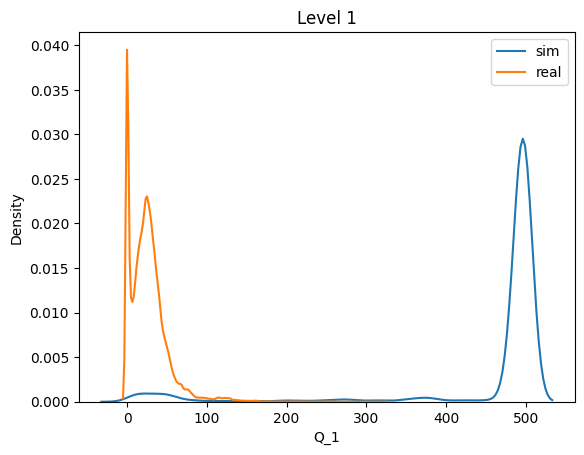

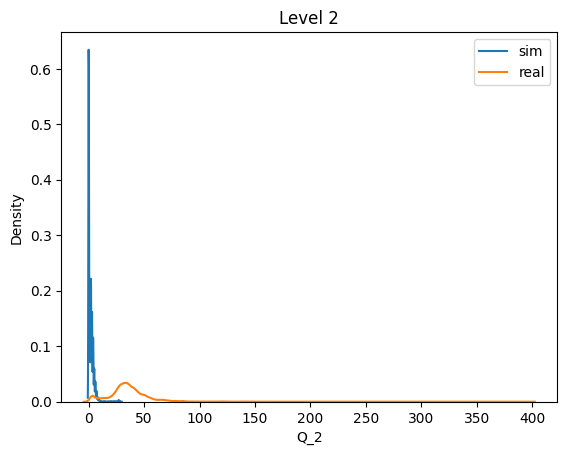

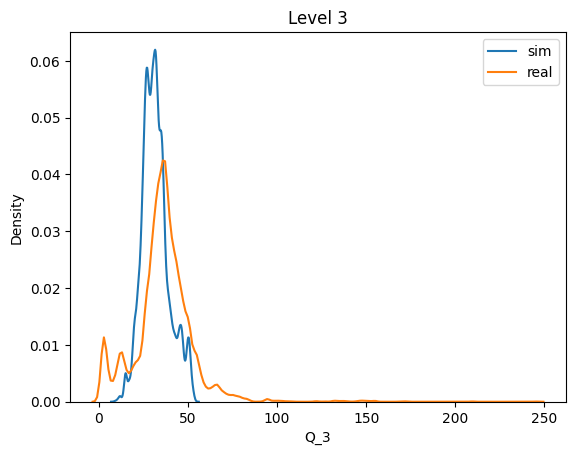

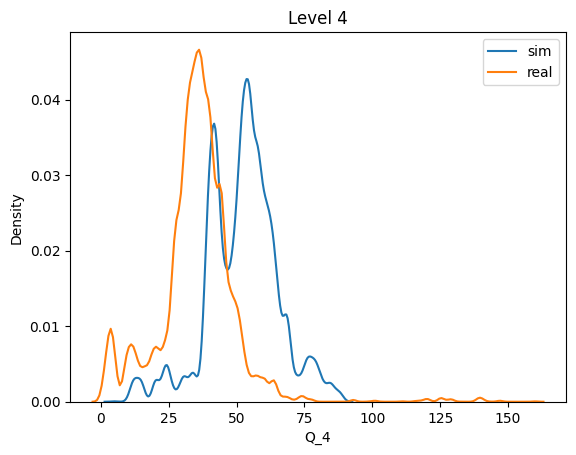

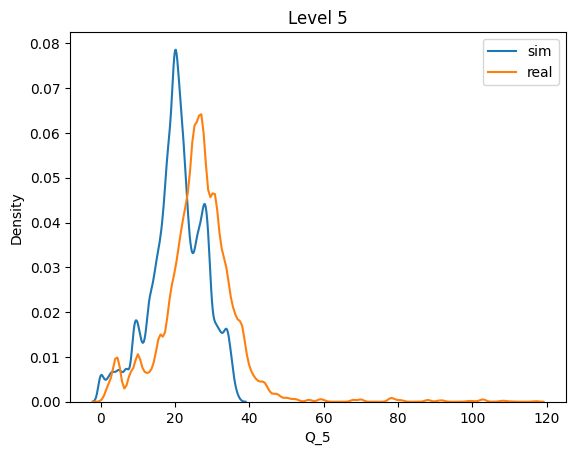

In [94]:
import seaborn as sns

for l in range(1, 6):
    col = f"Q_{l}"
    
    sns.kdeplot(df_sim[col], label="sim")
    sns.kdeplot(df_norm[col], label="real")
    
    plt.title(f"Level {l}")
    plt.legend()
    plt.show()

In [98]:
def conditional_event_rate(df, level):
    sub = df[np.abs(df["lvl"]) == level]
    
    bins = [0,2,5,10,20,50,100]
    
    for i in range(len(bins)-1):
        bmin, bmax = bins[i], bins[i+1]
        
        cond = (sub[f"Q_{level}"] >= bmin) & (sub[f"Q_{level}"] < bmax)
        sub_bin = sub[cond]
        
        if len(sub_bin) == 0:
            continue
        
        rate_L = (sub_bin["type"] == "L").mean()
        rate_C = (sub_bin["type"] == "C").mean()
        rate_M = (sub_bin["type"] == "M").mean()
        
        print(f"{bmin}-{bmax}: L={rate_L:.2f}, C={rate_C:.2f}, M={rate_M:.2f}")

In [99]:
print("Simulation")
conditional_event_rate(df_sim, level=1)
print("REal")
conditional_event_rate(df_norm, level=1)

Simulation
0-2: L=0.20, C=0.60, M=0.20
2-5: L=0.47, C=0.49, M=0.05
5-10: L=0.56, C=0.43, M=0.02
10-20: L=0.54, C=0.43, M=0.03
20-50: L=0.52, C=0.46, M=0.02
50-100: L=0.54, C=0.45, M=0.01
REal
0-2: L=0.52, C=0.44, M=0.04
2-5: L=0.45, C=0.32, M=0.23
5-10: L=0.48, C=0.37, M=0.15
10-20: L=0.50, C=0.42, M=0.08
20-50: L=0.51, C=0.42, M=0.08
50-100: L=0.50, C=0.40, M=0.10


In [100]:
lam_L, lam_C, lam_M = [], [], []

for _ in range(10000):
    l = model_intensities(model_level_1, q_val=10, last_event=0, hour_id=0)
    lam_L.append(l[0])
    lam_C.append(l[1])
    lam_M.append(l[2])

print(np.mean(lam_L), np.mean(lam_C), np.mean(lam_M))

6.472157955169678 4.88830041885376 0.15807905793190002


<Axes: >

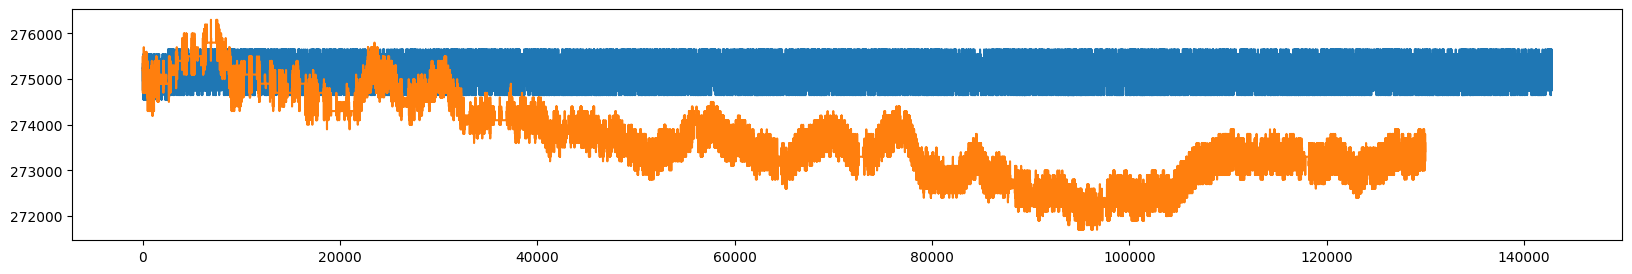

In [105]:
df_sim["price"].plot(figsize=(20, 3))
df_norm[:130000]["price"].plot(figsize=(20, 3))

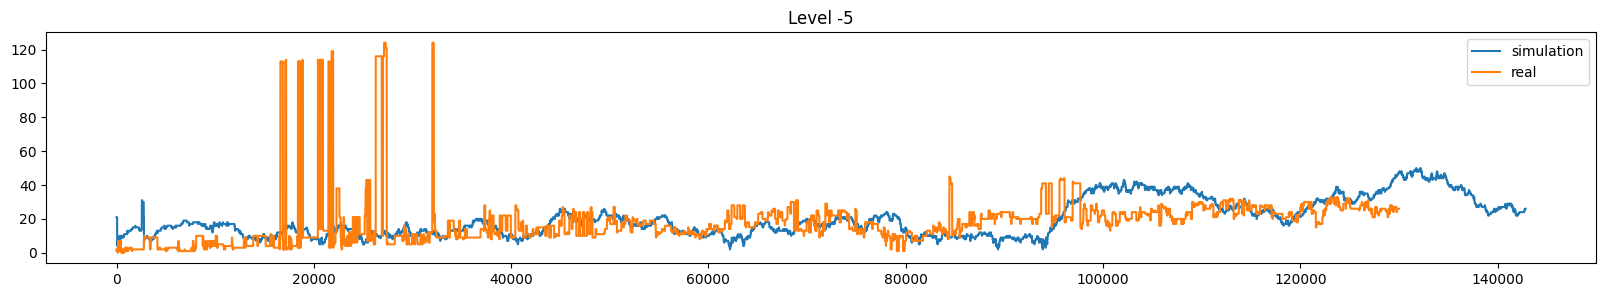

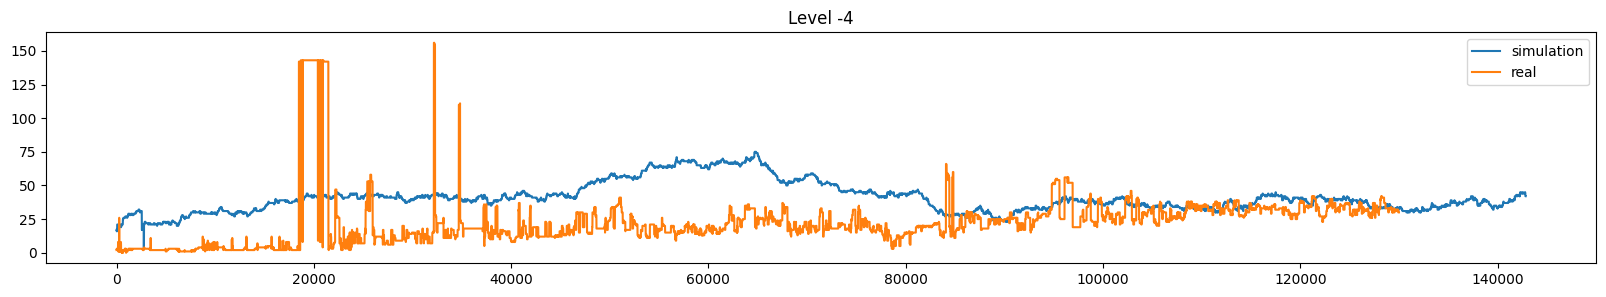

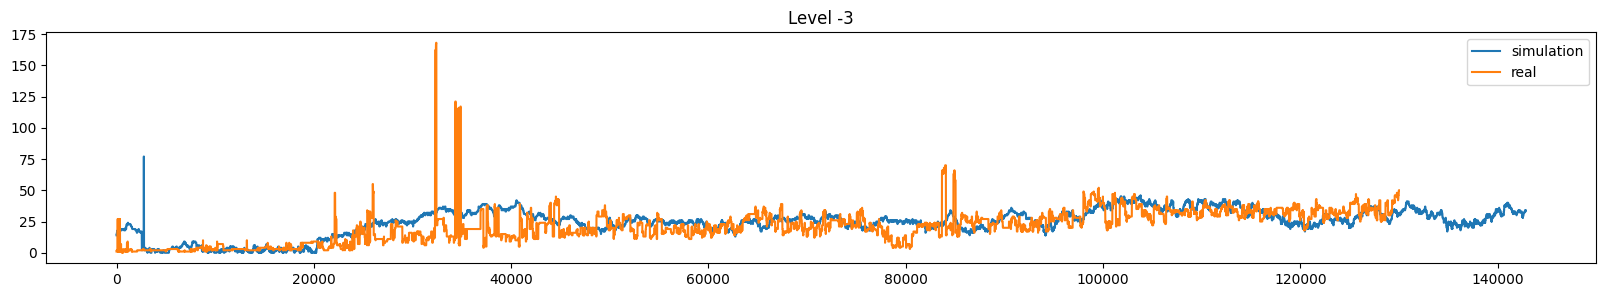

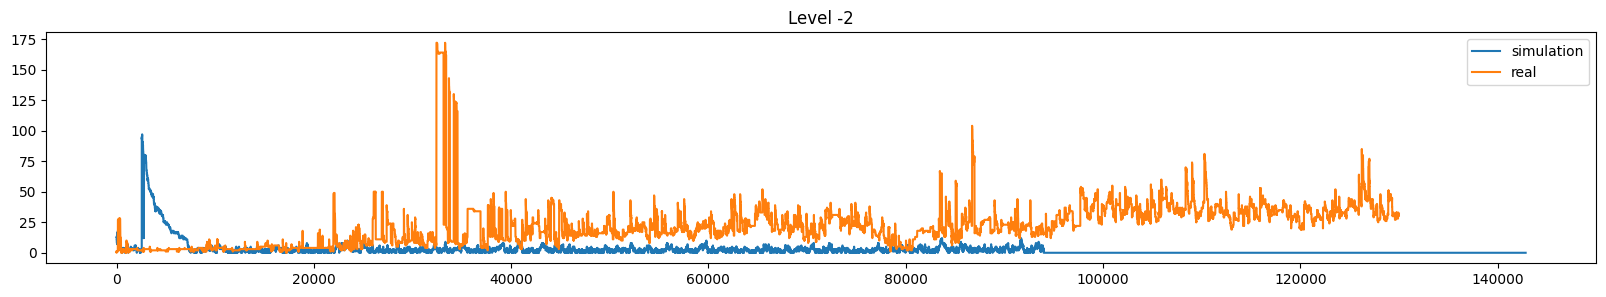

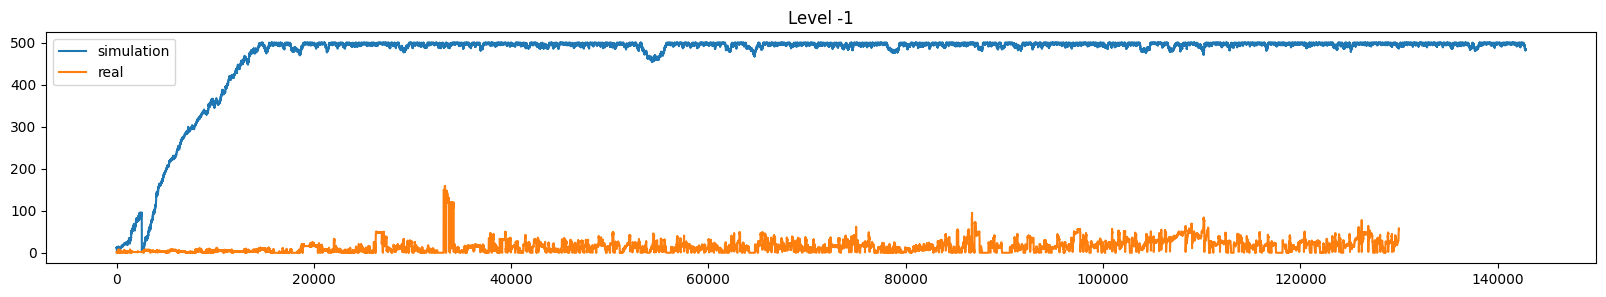

In [106]:
for i in range(-5,0):
    plt.figure(figsize=(20, 3))
    df_sim[f"Q_{i}"].plot(figsize=(20, 3), label="simulation")
    df_norm[f"Q_{i}"][:130000].plot(figsize=(20, 3), label="real")
    plt.legend()
    plt.title(f"Level {i}")

### Deuxième ESSAI ###

In [ ]:
class MDQRSimulator:
    def __init__(self, models_by_level, initial_prices, initial_queues, 
                 empirical_q_sampler, tick_size=100.0, start_time=34200.0):
        """
        models_by_level: dict mapping absolute level 1-5 to trained models
        initial_prices: dict of initial prices e.g., {1: 275200, -1: 275100, ...}
        initial_queues: dict of initial normalized queue sizes e.g., {1: 166, -1: 200, ...}
        empirical_q_sampler: function(level) -> int, to draw new queue sizes
        tick_size: float, gap between price levels
        start_time: float, simulation start time in seconds (e.g. 9:30 AM = 34200s)
        """
        self.models = models_by_level
        self.empirical_q_sampler = empirical_q_sampler
        self.tick_size = tick_size
        self.time = start_time
        
        self.levels = [-5, -4, -3, -2, -1, 1, 2, 3, 4, 5]
        
        # State tracking
        self.Q = {lvl: float(initial_queues[lvl]) for lvl in self.levels}
        self.P = {lvl: float(initial_prices[lvl]) for lvl in self.levels}
        self.pref = (self.P[1] + self.P[-1]) / 2.0
        
        # Features
        self.last_event = {lvl: 0 for lvl in self.levels}  # 0: L, 1: C, 2: M
        self.last_event_time = {lvl: start_time for lvl in self.levels}
        self.seg_id = 1
        
        self.history = []
        
    def step(self):
        rates = {}
        total_rate = 0.0
        hour_id = min(max(int(self.time / 3600) - 9, 0), 8) # Maps 9AM->0, 10AM->1...
        
        # 1. Compute intensities for all queues
        for lvl in self.levels:
            depth = abs(lvl)
            
            # Prepare tensors
            q_t = torch.tensor([self.Q[lvl]], dtype=torch.float32)
            le_t = torch.tensor([self.last_event[lvl]], dtype=torch.long)
            h_t = torch.tensor([hour_id], dtype=torch.long)
            
            with torch.no_grad():
                # Model returns [Limit_rate, Cancel_rate, Market_rate]
                intensities = self.models[depth](q_t, le_t, h_t).squeeze().numpy()
                
            # Floor at small epsilon to prevent strictly zero/negative probabilities
            intensities = np.maximum(intensities, 1e-6)
            rates[lvl] = intensities
            total_rate += np.sum(intensities)
            
        # 2. Draw global time increment (dtk)
        dtk = np.random.exponential(1.0 / total_rate)
        self.time += dtk
        
        # 3. Choose queue and event type
        flat_rates, flat_keys = [], []
        for lvl in self.levels:
            for idx, ev in enumerate(['L', 'C', 'M']):
                flat_rates.append(rates[lvl][idx])
                flat_keys.append((lvl, ev, idx))
                
        probs = np.array(flat_rates) / total_rate
        chosen_idx = np.random.choice(len(flat_keys), p=probs)
        chosen_lvl, ev_type_str, ev_type_idx = flat_keys[chosen_idx]
        
        # 4. Calculate level-specific dt and update state features
        dtk_l = self.time - self.last_event_time[chosen_lvl]
        self.last_event_time[chosen_lvl] = self.time
        self.last_event[chosen_lvl] = ev_type_idx
        
        # Update queue size
        impact = 1 if ev_type_str == 'L' else -1
        self.Q[chosen_lvl] += impact
        
        # 5. Record event prior to potential segment shifts
        record = {
            'time': self.time,
            'dtk': dtk,
            'dtk_l': dtk_l,
            'type': ev_type_str,
            'price': self.P[chosen_lvl],
            'lvl': chosen_lvl,
            'size': 1,
            'pref': self.pref,
        }
        for l in self.levels:
            record[f'P_{l}'] = self.P[l]
            record[f'Q_{l}'] = self.Q[l]
        record['seg_id'] = self.seg_id
        
        self.history.append(record)
        
        # 6. Endogenous Order Book shifting on best quote depletion
        if self.Q[chosen_lvl] <= 0:
            self.Q[chosen_lvl] = 0.0 # Strict bound
            if chosen_lvl == 1:
                self._shift_ask()
            elif chosen_lvl == -1:
                self._shift_bid()

    def _shift_ask(self):
        """Shifts Ask side down when best Ask is depleted."""
        for l in range(1, 5):
            self.P[l] = self.P[l+1]
            self.Q[l] = self.Q[l+1]
            self.last_event[l] = self.last_event[l+1]
            
        self.P[5] += self.tick_size
        self.Q[5] = float(self.empirical_q_sampler(5)) # Draw from empirical dist
        self.last_event[5] = 0
        
        self._reset_segment()

    def _shift_bid(self):
        """Shifts Bid side down when best Bid is depleted."""
        for l in range(-1, -5, -1):
            self.P[l] = self.P[l-1]
            self.Q[l] = self.Q[l-1]
            self.last_event[l] = self.last_event[l-1]
            
        self.P[-5] -= self.tick_size
        self.Q[-5] = float(self.empirical_q_sampler(-5))
        self.last_event[-5] = 0
        
        self._reset_segment()
        
    def _reset_segment(self):
        """Resets reference price and cross-queue timings."""
        self.pref = (self.P[1] + self.P[-1]) / 2.0
        self.seg_id += 1
        for lvl in self.levels:
            self.last_event_time[lvl] = self.time

    def simulate(self, num_events):
        for _ in range(num_events):
            self.step()
            
    def to_dataframe(self):
        """Exports history matching the exact requested format."""
        df = pd.DataFrame(self.history)
        
        # Order the columns exactly like the reference image
        order = ['time', 'dtk', 'dtk_l', 'type', 'price', 'lvl', 'size', 'pref']
        for i in range(1, 6):
            order.extend([f'P_{i}', f'Q_{i}', f'P_{-i}', f'Q_{-i}'])
        order.append('seg_id')
        
        return df[order]

In [123]:
from scipy.stats import gamma

def fit_gamma_queue_params(df, K=5, side="both", min_value=1e-8):
    """
    Fit une loi Gamma pour chaque niveau absolu.
    
    Retourne un dict :
        params[level] = {"shape": a, "scale": scale}
    où level = 1, 2, ..., K
    """
    params = {}

    for level in range(1, K + 1):
        samples = []

        if side in ["ask", "both"]:
            col_ask = f"Q_{level}"
            if col_ask in df.columns:
                x = df[col_ask].dropna().values
                x = x[x > 0]
                samples.append(x)

        if side in ["bid", "both"]:
            col_bid = f"Q_-{level}"
            if col_bid in df.columns:
                x = df[col_bid].dropna().values
                x = x[x > 0]
                samples.append(x)

        if len(samples) == 0:
            raise ValueError(f"No data found for level {level}")

        x_all = np.concatenate(samples)
        x_all = np.maximum(x_all, min_value)

        # fit avec loc forcé à 0
        shape, loc, scale = gamma.fit(x_all, floc=0)

        params[level] = {
            "shape": shape,
            "scale": scale,
            "mean": shape * scale,
            "n_obs": len(x_all),
        }

    return params

In [124]:
def sample_queue_size(level, q_max=None):
    """
    Tire une taille de queue depuis une Gamma fitée pour le niveau donné.
    Retourne un entier >= 1.
    """
    gamma_params = {
    1: {"shape": 1.7289423584987114, "scale": 18.848103522144264},
    2: {"shape": 2.809091909109615, "scale": 13.76733383523028},
    3: {"shape": 3.4859323695152464, "scale": 10.763319952287102},
    4: {"shape": 4.081954214601435, "scale": 8.960984795083762},
    5: {"shape": 4.908641549661595, "scale": 5.663716053979379},
    }
    
    if abs(level) not in gamma_params:
        raise ValueError(f"Missing gamma parameters for level {level}")

    shape = gamma_params[abs(level)]["shape"]
    scale = gamma_params[abs(level)]["scale"]

    q = np.random.gamma(shape=shape, scale=scale)

    # conversion en taille entière
    q = max(1, int(round(q)))

    if q_max is not None:
        q = min(q, q_max)

    return q

In [130]:
# 1. Provide initial prices and queues
initial_P = {
    1: 275200.0, 2: 275300.0, 3: 275400.0, 4: 275500.0, 5: 275600.0,
    -1: 275100.0, -2: 275000.0, -3: 274900.0, -4: 274800.0, -5: 274700.0
}
initial_Q = {
     1: 10,  2: 10,  3: 10,  4: 10, 5 : 10,
    -1: 100, -2: 100, -3: 100, -4: 100, -5: 100
}

# 3. Instantiate and run
simulator = MDQRSimulator(
    models_by_level=models_by_level, 
    initial_prices=initial_P, 
    initial_queues=initial_Q, 
    empirical_q_sampler=sample_queue_size,
    tick_size=100.0, 
    start_time=34200.0 # 09:30:00 AM
)

num_sims = 100_000
simulator.simulate(num_events=num_sims)
df_simulated = simulator.to_dataframe()
df_simulated

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.023788,0.023788,0.023788,M,275100.0,-1,1,275150.0,275200.0,10.0,...,100.0,275500.0,10.0,274800.0,100.0,275600.0,10.0,274700.0,100.0,1
1,34200.024753,0.000964,0.000964,M,275100.0,-1,1,275150.0,275200.0,10.0,...,100.0,275500.0,10.0,274800.0,100.0,275600.0,10.0,274700.0,100.0,1
2,34200.029484,0.004731,0.004731,L,275100.0,-1,1,275150.0,275200.0,10.0,...,100.0,275500.0,10.0,274800.0,100.0,275600.0,10.0,274700.0,100.0,1
3,34200.045861,0.016377,0.016377,L,275100.0,-1,1,275150.0,275200.0,10.0,...,100.0,275500.0,10.0,274800.0,100.0,275600.0,10.0,274700.0,100.0,1
4,34200.057931,0.012070,0.012070,L,275100.0,-1,1,275150.0,275200.0,10.0,...,100.0,275500.0,10.0,274800.0,100.0,275600.0,10.0,274700.0,100.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,36280.947338,0.049258,0.056584,C,275200.0,1,1,275150.0,275200.0,3823.0,...,34.0,275500.0,47.0,274800.0,45.0,275600.0,22.0,274700.0,47.0,1
99996,36281.150580,0.203241,0.203241,C,275200.0,1,1,275150.0,275200.0,3822.0,...,34.0,275500.0,47.0,274800.0,45.0,275600.0,22.0,274700.0,47.0,1
99997,36281.192534,0.041954,0.294453,L,275100.0,-1,1,275150.0,275200.0,3822.0,...,34.0,275500.0,47.0,274800.0,45.0,275600.0,22.0,274700.0,47.0,1
99998,36281.206851,0.014318,0.056272,L,275200.0,1,1,275150.0,275200.0,3823.0,...,34.0,275500.0,47.0,274800.0,45.0,275600.0,22.0,274700.0,47.0,1


In [127]:
df_real = df_norm[:num_sims]
df_real

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,36450.128396,0.000043,0.006151,L,272500,1,1,272450.0,272500.0,33,...,40,272800.0,33,272100.0,28,272900.0,20,272000.0,25,422
99996,36450.128567,0.000172,0.000172,L,272500,1,1,272450.0,272500.0,33,...,40,272800.0,33,272100.0,28,272900.0,20,272000.0,25,422
99997,36450.130684,0.002117,0.002117,C,272500,1,3,272450.0,272500.0,31,...,40,272800.0,33,272100.0,28,272900.0,20,272000.0,25,422
99998,36450.134326,0.003642,0.005973,L,272400,-1,1,272450.0,272500.0,31,...,40,272800.0,33,272100.0,28,272900.0,20,272000.0,25,422


<Axes: >

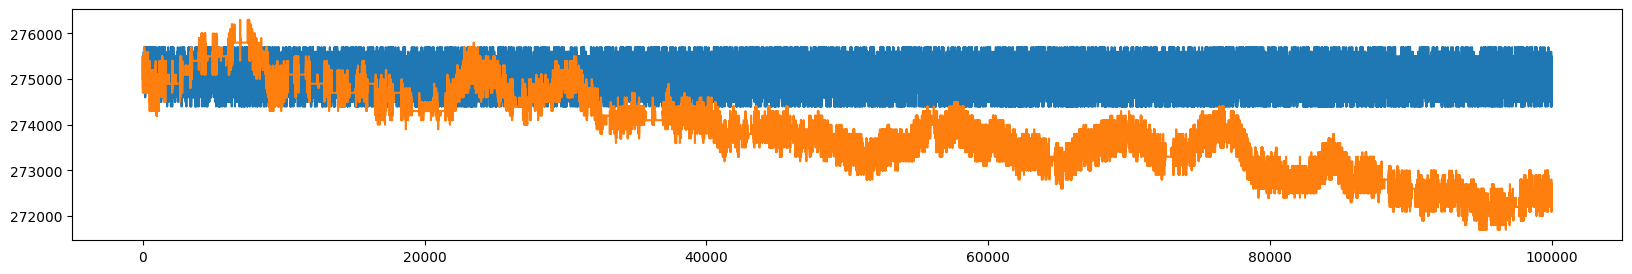

In [129]:
df_simulated["price"].plot(figsize=(20, 3))
df_real["price"].plot(figsize=(20, 3))

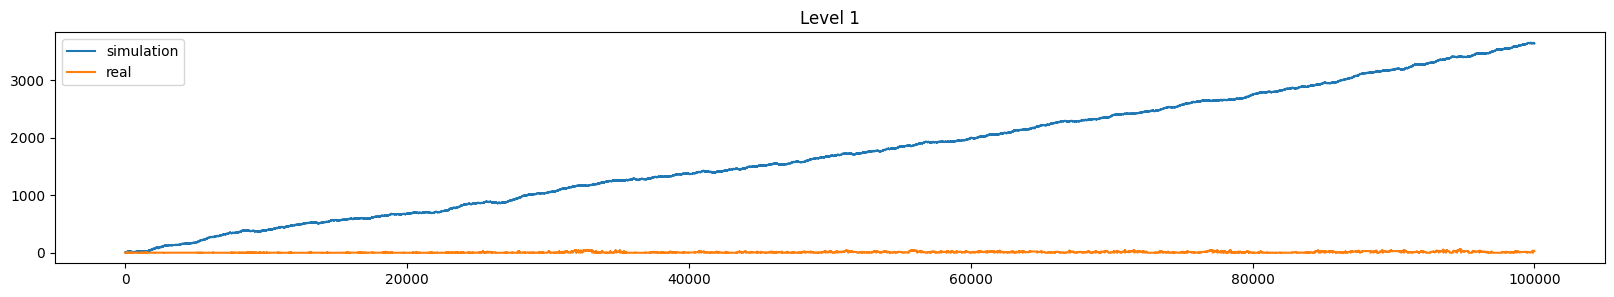

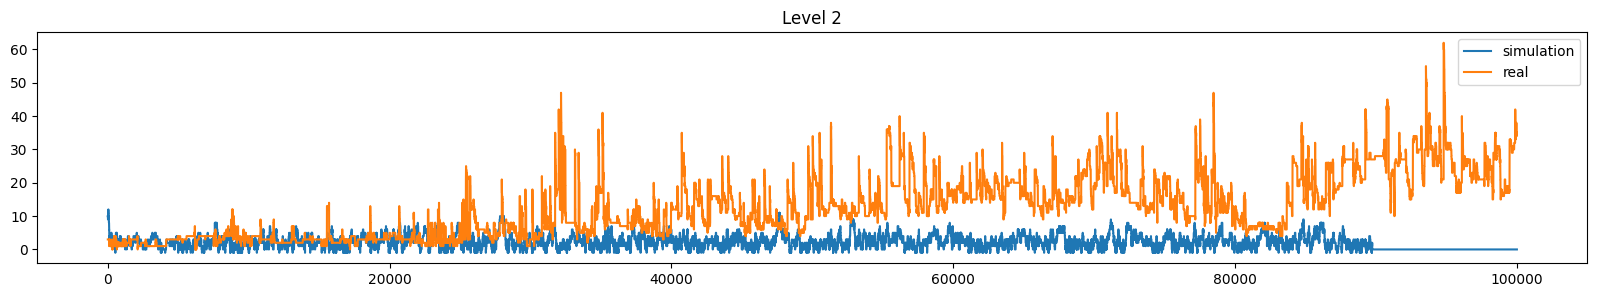

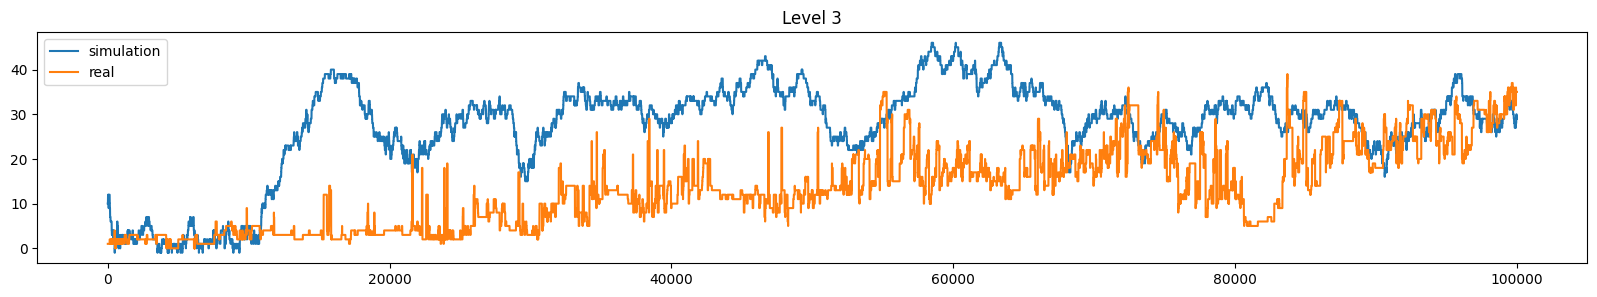

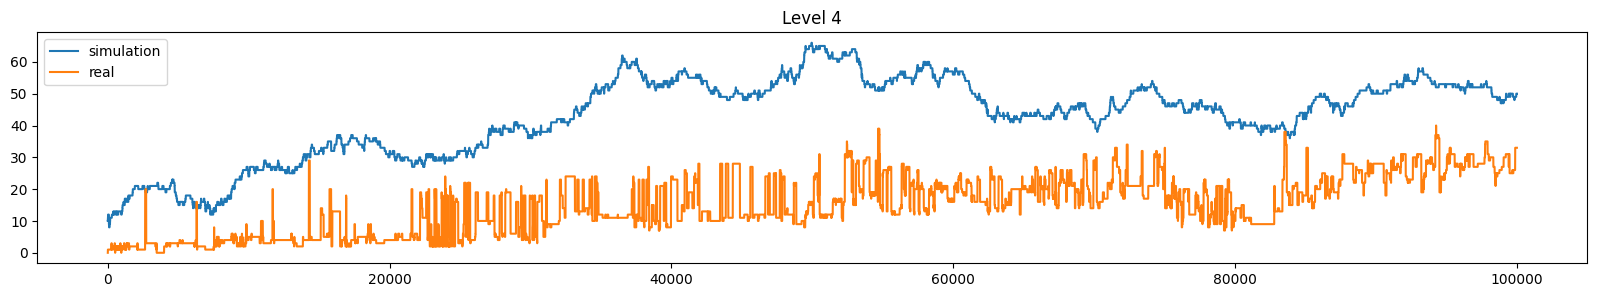

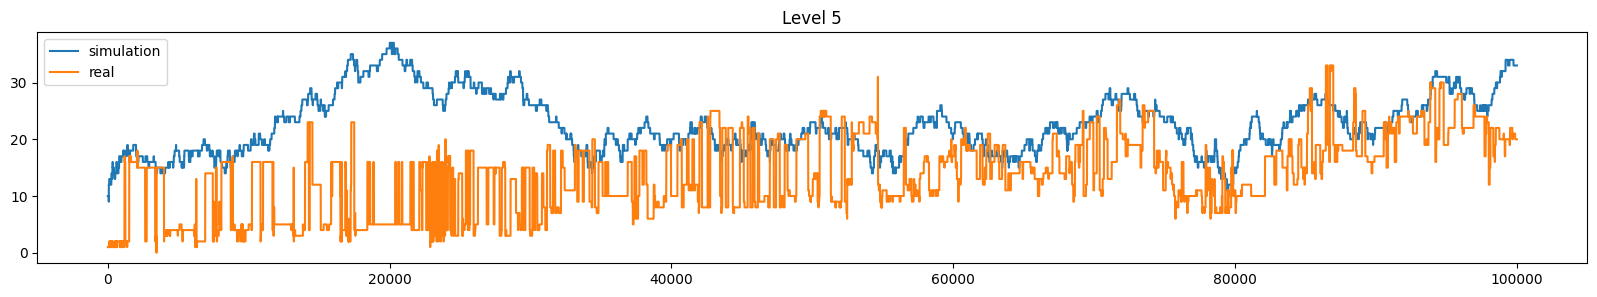

In [128]:
for i in range(1,6):
    plt.figure(figsize=(20, 3))
    df_simulated[f"Q_{i}"].plot(figsize=(20, 3), label="simulation")
    df_real[f"Q_{i}"].plot(figsize=(20, 3), label="real")
    plt.legend()
    plt.title(f"Level {i}")

### Transition Matrixes ###

In [ ]:
df_level_1 = dfs_by_abs_level[1].copy()
display(df_level_1)
display(df_train_1)

,event_id,dtk_l,q,hour_last_event,last_event_id
0,0,0.162572,1,0,1
1,0,0.000007,2,0,0
2,0,0.000002,2,0,0
3,1,0.000094,2,0,0
4,0,0.000000,2,0,1
...,...,...,...,...,...
392088,1,0.010125,256,6,1
392089,1,0.206373,253,6,1
392090,0,0.014818,252,6,1
392091,1,0.011408,254,6,0


{'q': tensor([  1.,   2.,   2.,  ..., 252., 254., 183.]),
 'y': tensor([0, 0, 0,  ..., 0, 1, 0]),
 'dt': tensor([1.6257e-01, 6.8950e-06, 1.5020e-06,  ..., 1.4818e-02, 1.1408e-02,
         7.9201e-02]),
 'last_event': tensor([1, 0, 0,  ..., 1, 0, 1]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

In [ ]:
from dqrfunctions import transition_real, transition_dqr

df_level_1 = dfs_by_abs_level[1].copy()

event_id_np = df_level_1["event_id"].to_numpy()
last_id_np  = df_level_1["last_event_id"].to_numpy()
# DQR: last_event_id must match X lines format (torch)
last_id_t = torch.tensor(last_id_np, dtype=torch.long)

T_real = transition_real(event_id_np, last_id_np, n_events=3)
T_dqr = transition_dqr(
                        model=model_level_1,
                        data=df_train_1,
                        last_event_id=last_id_t,
                        n_events=3)
T_qr = qr_matrix.to_numpy()

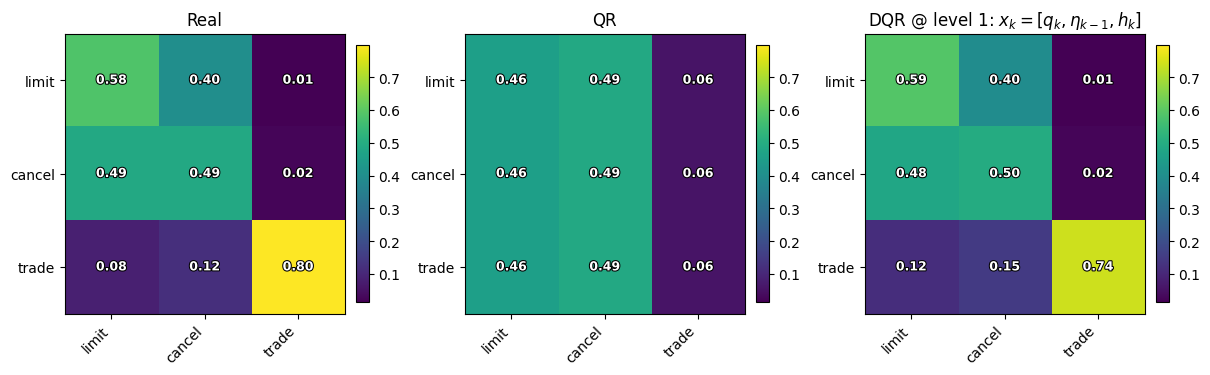

In [ ]:
from dqrfunctions import plot_two_heatmaps, plot_three_heatmaps

EVENT_NAMES = ["limit", "cancel", "trade"]
dqr_title = r"DQR @ level 1: $x_k=[q_k,\eta_{k-1},h_k]$"

fig = plot_three_heatmaps(T_real, T_qr, T_dqr, labels=EVENT_NAMES, dqr_title=dqr_title)
plt.show()

In [ ]:
from dqrfunctions import compute_hourly_intensity, compute_real_hourly_intensity
hourly_dqr = compute_hourly_intensity(model_level_1, df_train_1, df_level_1["hour_last_event"].values)
hourly_real = compute_real_hourly_intensity(df_level_1, trade_id=2)

#from qrFunctions import compute_hourly_intensity_qr
#hourly_qr, constant_hourly_qr = compute_hourly_intensity_qr(lambdas, df_train)

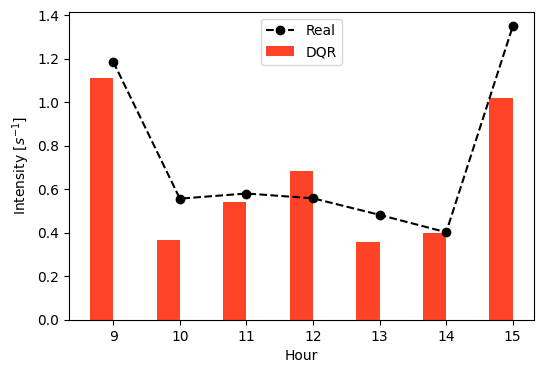

In [ ]:
width = 0.35
x = hourly_dqr.index.values + 9
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - width/2, hourly_dqr.values, width=width, color="#FF4327", label="DQR")
ax.plot(x, hourly_real.values, "o--", color="black", label="Real")
#ax.plot(hourly_qr.index, hourly_qr.values, label="QR", marker='^', linestyle='--', color='darkblue')
#ax.axhline(constant_hourly_qr, xmin=x.min(), xmax=x.max(), color='black', linestyle='-', label='QR (Constant)')
ax.set_xlabel("Hour")
ax.set_ylabel(r"Intensity [$s^{-1}$]")
ax.set_xticks(x)
ax.legend()
plt.show()